In [28]:
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
countries = ["BZN|IT-North", "France (FR)", "Poland (PL)", "Switzerland (CH)"]
short_countries = ["IT", "FR", "PO", "CH"]


'Data for BZN|IT-North'

'Mean load: 17.66 GW ± 4.35 GW'

'Variation (std/mean): 24.65%'

'Median load: 17.16 GW (Q1: 14.08 GW, Q3: 21.27 GW)'

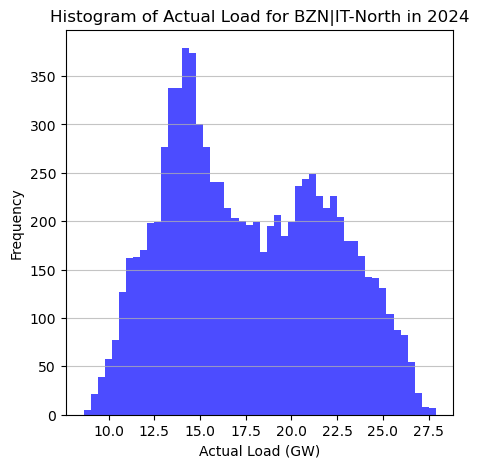

'Data for France (FR)'

'Mean load: 49.05 GW ± 9.83 GW'

'Variation (std/mean): 20.05%'

'Median load: 47.55 GW (Q1: 41.94 GW, Q3: 55.50 GW)'

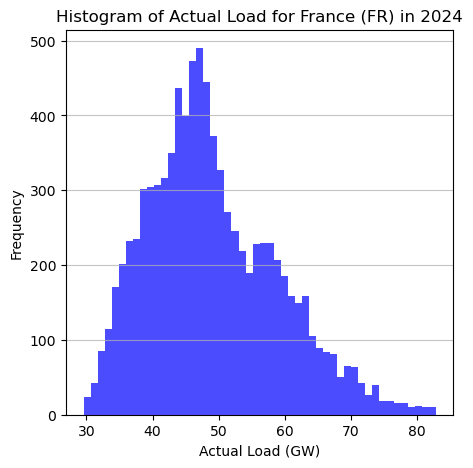

'Data for Poland (PL)'

'Mean load: 18.26 GW ± 3.05 GW'

'Variation (std/mean): 16.69%'

'Median load: 18.37 GW (Q1: 15.68 GW, Q3: 20.50 GW)'

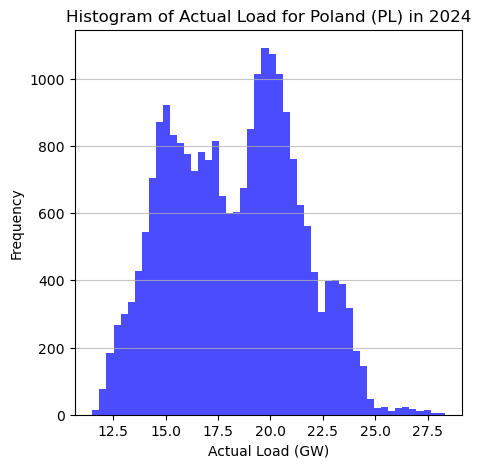

'Data for Switzerland (CH)'

'Mean load: 6.79 GW ± 1.12 GW'

'Variation (std/mean): 16.52%'

'Median load: 6.81 GW (Q1: 6.02 GW, Q3: 7.56 GW)'

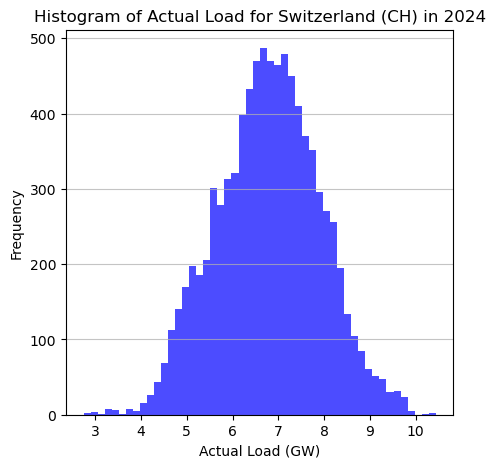

In [31]:
# Read CSV data
data_frames = {}
for country, short_country in zip(countries, short_countries):
    file_path = f"./{short_country}.csv"
    # "Time (CET/CEST)","Day-ahead Total Load Forecast [MW] - Germany (DE)","Actual Total Load [MW] - Germany (DE)"
    # get a list of only the actual load
    df = pd.read_csv(file_path, usecols=["Time (CET/CEST)", f"Actual Total Load [MW] - {country}"])
    df.rename(columns={f"Actual Total Load [MW] - {country}": "Actual Load"}, inplace=True)

    # Print
    display("Data for " + country)
    # mean +- std
    mean_load = df["Actual Load"].mean()
    std_load = df["Actual Load"].std()
    display(f"Mean load: {mean_load/1000:.2f} GW ± {std_load/1000:.2f} GW")
    display(f"Variation (std/mean): {std_load/mean_load*100:.2f}%")
    
    # median and quartiles
    median_load = df["Actual Load"].median()
    q1_load = df["Actual Load"].quantile(0.25)
    q3_load = df["Actual Load"].quantile(0.75)
    display(f"Median load: {median_load/1000:.2f} GW (Q1: {q1_load/1000:.2f} GW, Q3: {q3_load/1000:.2f} GW)")
    
    # Plot an histogram of the load values
    plt.figure(figsize=(5, 5))
    plt.hist(df["Actual Load"]/1000, bins=50, color='blue', alpha=0.7)
    plt.title(f'Histogram of Actual Load for {country} in 2024')
    plt.xlabel('Actual Load (GW)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    # plt.savefig(f'./Total Loads/{country}_load_histogram_2024.png')
    plt.show()
    
